In [2]:
!pip install ucimlrepo

# Week 3: Model Interpretation and Visualization

## 1. Logistic Regression Confusion Matrix

A confusion matrix shows how the model's predicted classes compare with the actual classes.

In [12]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
# Import pyplot for graphing, Display for making a confusion matrix into a graph
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [14]:
# Load dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

# Handle missing values

X = X.fillna(X.median())

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Scale data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train.values.ravel())

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.5409836065573771

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.38      0.25      0.30        12
           2       0.22      0.22      0.22         9
           3       0.17      0.29      0.21         7
           4       0.00      0.00      0.00         4

    accuracy                           0.54        61
   macro avg       0.32      0.33      0.32        61
weighted avg       0.51      0.54      0.52        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


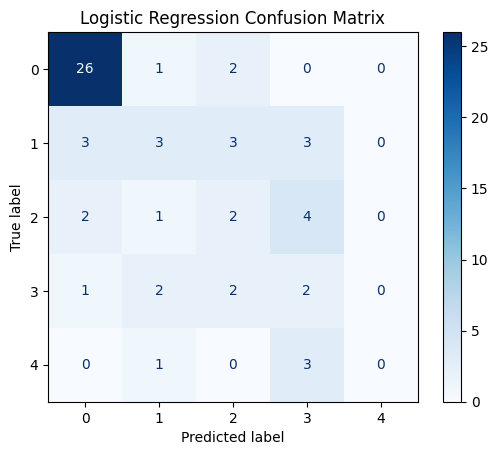

In [15]:
# Create the confusion metric
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test.values.ravel(),
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.savefig(
    "logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Logistic Regression model performed well for class 0 but had difficulty predicting classes 1–4. It did not correctly identify any class 4 patients. This may be related to the small number of class 4 samples and the imbalance in the dataset.

In [23]:
# Get coefficients from Logistic Regression
coefficients = model.coef_[0]

# Show each feature and its coefficient
for feature, coef in zip(X.columns, coefficients):
    print(feature, ":", round(coef, 3))

age : -0.065
sex : -0.582
cp : -0.556
trestbps : -0.33
chol : -0.305
fbs : 0.248
restecg : -0.173
thalach : 0.239
exang : -0.402
oldpeak : -0.432
slope : -0.443
ca : -1.068
thal : -0.451


In [24]:
#Create a Data frame
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(
    by="Coefficient"
)

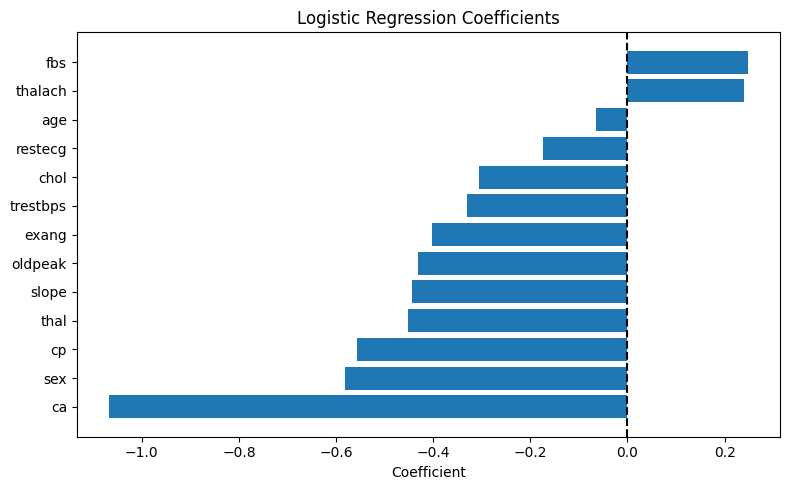

In [25]:
plt.figure(figsize=(8,5))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"]
)

plt.axvline(
    x=0,
    color="black",
    linestyle="--"
)

plt.title("Logistic Regression Coefficients")

plt.xlabel("Coefficient")

plt.tight_layout()

plt.savefig(
    "logistic_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Higher positive coefficients increases the predicted probability of heart disease.
Higher negative coefficients decrease the predicted probability of heart disease.

## Random Forest confusion matrix

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train.values.ravel())

# Make predictions
rf_pred = rf_model.predict(X_test)

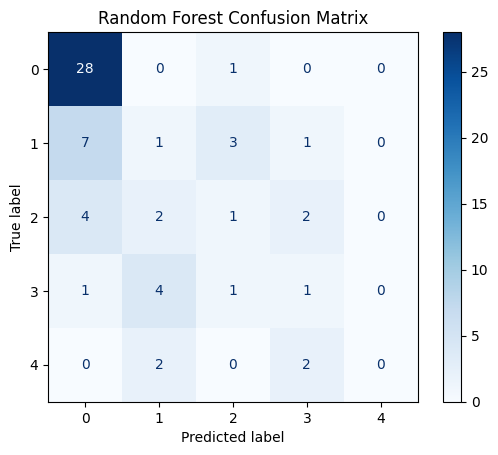

In [18]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test.values.ravel(),
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The Random Forest model also performed best for class 0 and had difficulty predicting the smaller classes. Class 4 was not correctly identified, which may be related to the small number of class 4 patients in the dataset.

In [20]:
# How important each feature is
importance = rf_model.feature_importances_

# Display each feature and its importance, larger number = the feature contributed more to the model's decisions
for feature, score in zip(X.columns, importance):
    print(feature, ":", round(score, 3))

age : 0.111
sex : 0.033
cp : 0.084
trestbps : 0.092
chol : 0.112
fbs : 0.021
restecg : 0.029
thalach : 0.142
exang : 0.042
oldpeak : 0.123
slope : 0.047
ca : 0.094
thal : 0.068


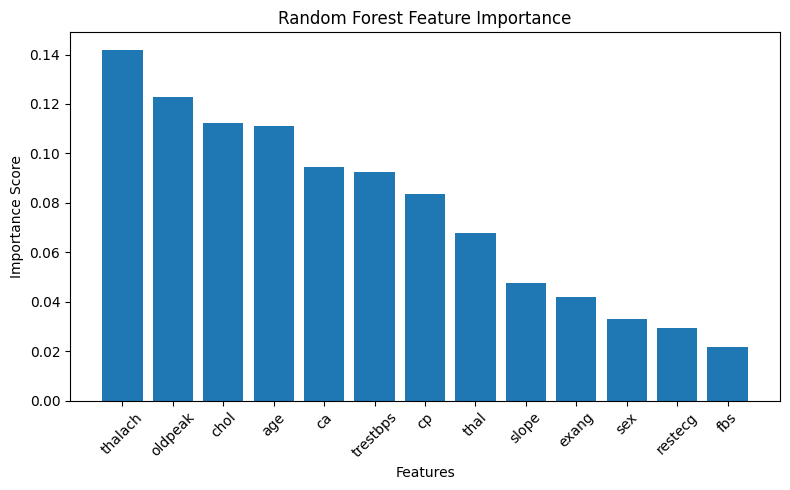

In [22]:
#Import pandas as pd
import pandas as pd
# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort from highest to lowest
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xticks(rotation=45)

plt.title("Random Forest Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparsion

In [26]:
#Calculate the value of 2 models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)
lr_recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)
lr_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted",
    zero_division=0
)

In [28]:
# Make the comparsion table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-score": [
        lr_f1,
        rf_f1
    ]
})

# Round the numbers to three decimal places
comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.541,0.512,0.541,0.521
1,Random Forest,0.508,0.398,0.508,0.442


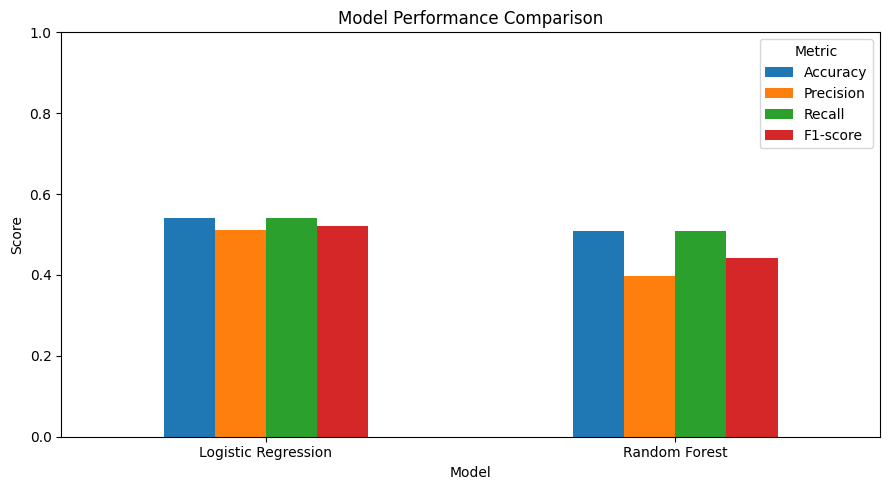

In [29]:
# To draw the comparsion graph
# Change the table format for plotting
comparison_plot = comparison.set_index("Model")

# Create the bar chart
comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Model Comparison

The models were evaluated using accuracy, weighted precision, weighted recall, and weighted F1-score.

Logistic Regression performed slightly better than Random Forest in this experiment. However, the weighted scores are influenced by the larger number of class 0 patients. Therefore, the classification reports and confusion matrices are also important for evaluating performance across individual disease classes.